# Experiment 1: Sweeping N_TOKENS and Using the Roofline Model

We sweep N_TOKENS on each architecture for the decode and prefill workloads. We plot the per-Einsum energy, latency, and throughputs. The throughputs are plotted on the calculated roofline plots for the architectures.

## Setup

In [20]:
import os
import numpy as np
import pandas as pd
import accelforge as af
import matplotlib.pyplot as plt
from pathlib import Path
from adjustText import adjust_text

models_dir = Path("../models")

AIM_ARCH = models_dir / "arches" / "aim_only_no_fusion.yaml"
TPU_ARCH = models_dir / "arches" / "tpu_only_no_fusion.yaml"
HYBRID_ARCH = models_dir / "arches" / "tpu_aim_hybrid_no_fusion.yaml"

DECODE_WORKLOAD = models_dir / "workloads" / "gpt3_6.7B_kv_cache_decode.yaml"
PREFILL_WORKLOAD = models_dir / "workloads" / "gpt3_6.7B_kv_cache_prefill.yaml"

FREQ = {
    "TPU": 1.05e9,
    "AiM": 1e9
}

BATCH_SIZE = 1

def best_energy_latency_product(mapping):
    energies = mapping.energy()
    latencies = mapping.latency()

    if not isinstance(energies, (list, tuple)):
        return mapping, energies, latencies

    idx = min(range(len(energies)), key=lambda i: energies[i] * latencies[i])
    return mapping[idx], energies[idx], latencies[idx]

caches_dir = Path("caches")

DECODE_CACHE_FILE = caches_dir / "decode_results_cache.csv"
PREFILL_CACHE_FILE = caches_dir / "prefill_results_cache.csv"

PLOT_DIR = "plots/"

## Evaluating Decode

In [21]:
DECODE_CACHE_FILE = "caches/decode_results_cache.csv"
if os.path.exists(DECODE_CACHE_FILE):
    df_cache = pd.read_csv(DECODE_CACHE_FILE)
    done_tokens = set(df_cache["N_TOKENS"].unique())
else:
    df_cache = pd.DataFrame()
    done_tokens = set()

records = []

for N_TOKENS in [1024, 4096, 8192]:
    if N_TOKENS in done_tokens:
        print(f"Skipping {N_TOKENS}, already cached")
        continue

    print(f"Num Tokens: {N_TOKENS}")
    aim_spec = af.Spec.from_yaml(
        AIM_ARCH,
        DECODE_WORKLOAD,
        jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
    )

    tpu_spec = af.Spec.from_yaml(
        TPU_ARCH,
        DECODE_WORKLOAD,
        jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
    )

    hybrid_spec = af.Spec.from_yaml(
        HYBRID_ARCH,
        DECODE_WORKLOAD,
        jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
    )

    aim_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    aim_mapping = aim_spec.map_workload_to_arch(print_progress=True)

    tpu_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    tpu_mapping = tpu_spec.map_workload_to_arch(print_progress=True)

    hybrid_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    hybrid_mapping = hybrid_spec.map_workload_to_arch(print_progress=True)

    BEST_AIM_MAPPING, aim_e, aim_l = best_energy_latency_product(aim_mapping)
    BEST_TPU_MAPPING, tpu_e, tpu_l = best_energy_latency_product(tpu_mapping)
    BEST_HYBRID_MAPPING, hybrid_e, hybrid_l = best_energy_latency_product(hybrid_mapping)

    ### Einsum allocation: AiM v TPU
    best_hybrid_mapping_energy = BEST_HYBRID_MAPPING.energy(per_einsum=True)
    best_hybrid_mapping_latency = BEST_HYBRID_MAPPING.latency(per_einsum=True)

    mapping_col = "Total<SEP>mapping"
    einsum_allocation = {}
    for ein in best_hybrid_mapping_energy:
        ein_col = f"{ein}<SEP>mapping"
        mapping_str = str(BEST_HYBRID_MAPPING.data[ein_col][0])

        if "TPU_MAC" in mapping_str or "TPU_ScalarUnit" in mapping_str:
            einsum_allocation[ein] = "TPU"
        elif "PU_MAC" in mapping_str:
            einsum_allocation[ein] = "AiM"
        else:
            einsum_allocation[ein] = "Unknown"

    ### Per einsum energy and latency
    einsum_names = [e.name for e in hybrid_spec.workload.einsums]
    for label, mapping in [("AiM", BEST_AIM_MAPPING), ("TPU", BEST_TPU_MAPPING), ("Hybrid", BEST_HYBRID_MAPPING)]:
        eng = mapping.energy(per_einsum=True)
        lat = mapping.latency(per_einsum=True)

        for name in einsum_names:
            computational_intensity = hybrid_spec.workload.get_compute_intensity(name)

            computes = hybrid_spec.workload.n_computes(einsum_name=name)
            if label == "AiM":
                cycles = lat[name] * FREQ["AiM"]
            elif label == "TPU":
                cycles = lat[name] * FREQ["TPU"]
            else:
                if einsum_allocation.get(name, None) == "AiM":
                    cycles = lat[name] * FREQ["AiM"]
                else:
                    cycles = lat[name] * FREQ["TPU"]
            throughput = computes / cycles

            records.append({
                "N_TOKENS": N_TOKENS,
                "einsum": name,
                "arch": label,
                "energy": eng[name],
                "latency": lat[name],
                "computes": computes,
                "ops_per_tensor_element": computational_intensity,
                "ops_per_cycle": throughput,
                "allocation": einsum_allocation.get(name, None) if label == "Hybrid" else None
            })

    df_new = pd.DataFrame(records)
    df_new.to_csv(DECODE_CACHE_FILE, mode="a", header=not os.path.exists(DECODE_CACHE_FILE), index=False)

    records = []

Skipping 1024, already cached
Skipping 4096, already cached
Skipping 8192, already cached


## Evaluating Prefill

In [22]:
PREFILL_CACHE_FILE = "caches/prefill_results_cache.csv"
if os.path.exists(PREFILL_CACHE_FILE):
    df_cache = pd.read_csv(PREFILL_CACHE_FILE)
    done_tokens = set(df_cache["N_TOKENS"].unique())
else:
    df_cache = pd.DataFrame()
    done_tokens = set()

records = []

for N_TOKENS in [1024, 4096, 8192]:
    if N_TOKENS in done_tokens:
        print(f"Skipping {N_TOKENS}, already cached")
        continue

    print(f"Num Tokens: {N_TOKENS}")
    aim_spec = af.Spec.from_yaml(
        AIM_ARCH,
        PREFILL_WORKLOAD,
        jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
    )

    tpu_spec = af.Spec.from_yaml(
        TPU_ARCH,
        PREFILL_WORKLOAD,
        jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
    )

    hybrid_spec = af.Spec.from_yaml(
        HYBRID_ARCH,
        PREFILL_WORKLOAD,
        jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
    )

    aim_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    aim_mapping = aim_spec.map_workload_to_arch(print_progress=True)

    tpu_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    tpu_mapping = tpu_spec.map_workload_to_arch(print_progress=True)

    hybrid_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    hybrid_mapping = hybrid_spec.map_workload_to_arch(print_progress=True)

    BEST_AIM_MAPPING, aim_e, aim_l = best_energy_latency_product(aim_mapping)
    BEST_TPU_MAPPING, tpu_e, tpu_l = best_energy_latency_product(tpu_mapping)
    BEST_HYBRID_MAPPING, hybrid_e, hybrid_l = best_energy_latency_product(hybrid_mapping)

    ### Einsum allocation: AiM v TPU
    best_hybrid_mapping_energy = BEST_HYBRID_MAPPING.energy(per_einsum=True)
    best_hybrid_mapping_latency = BEST_HYBRID_MAPPING.latency(per_einsum=True)

    mapping_col = "Total<SEP>mapping"
    einsum_allocation = {}
    for ein in best_hybrid_mapping_energy:
        ein_col = f"{ein}<SEP>mapping"
        mapping_str = str(BEST_HYBRID_MAPPING.data[ein_col][0])

        if "TPU_MAC" in mapping_str or "TPU_ScalarUnit" in mapping_str:
            einsum_allocation[ein] = "TPU"
        elif "PU_MAC" in mapping_str:
            einsum_allocation[ein] = "AiM"
        else:
            einsum_allocation[ein] = "Unknown"

    ### Per einsum energy and latency
    einsum_names = [e.name for e in hybrid_spec.workload.einsums]
    for label, mapping in [("AiM", BEST_AIM_MAPPING), ("TPU", BEST_TPU_MAPPING), ("Hybrid", BEST_HYBRID_MAPPING)]:
        eng = mapping.energy(per_einsum=True)
        lat = mapping.latency(per_einsum=True)

        for name in einsum_names:
            computational_intensity = hybrid_spec.workload.get_compute_intensity(name)

            computes = hybrid_spec.workload.n_computes(einsum_name=name)
            if label == "AiM":
                cycles = lat[name] * FREQ["AiM"]
            elif label == "TPU":
                cycles = lat[name] * FREQ["TPU"]
            else:
                if einsum_allocation.get(name, None) == "AiM":
                    cycles = lat[name] * FREQ["AiM"]
                else:
                    cycles = lat[name] * FREQ["TPU"]
            throughput = computes / cycles

            records.append({
                "N_TOKENS": N_TOKENS,
                "einsum": name,
                "arch": label,
                "energy": eng[name],
                "latency": lat[name],
                "computes": computes,
                "ops_per_tensor_element": computational_intensity,
                "ops_per_cycle": throughput,
                "allocation": einsum_allocation.get(name, None) if label == "Hybrid" else None
            })

    df_new = pd.DataFrame(records)
    df_new.to_csv(PREFILL_CACHE_FILE, mode="a", header=not os.path.exists(PREFILL_CACHE_FILE), index=False)

    records = []

Skipping 1024, already cached
Skipping 4096, already cached
Skipping 8192, already cached


## Plotting Functions

In [25]:
def plot_energy_and_latency_breakdowns(file_name, save_name = None):
    plt.rcParams.update({'font.size': 20})

    df = pd.read_csv(file_name)

    for n in df["N_TOKENS"].unique():
        sub = df[df["N_TOKENS"] == n]

        einsums = sub["einsum"].unique()
        x = np.arange(len(einsums))
        width = 0.25

        fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

        # Latency
        ax = axes[0]
        for i, arch in enumerate(["AiM", "TPU", "Hybrid"]):
            d = sub[sub["arch"] == arch].set_index("einsum").reindex(einsums)
            ax.bar(x + i * width, d["latency"], width, label=arch)
        ax.grid(True, which="both", linestyle="--")

        ax.set_ylabel("Latency (s)")
        ax.set_title(f"N_TOKENS = {n}")
        ax.legend()

        # Energy
        ax = axes[1]
        for i, arch in enumerate(["AiM", "TPU", "Hybrid"]):
            d = sub[sub["arch"] == arch].set_index("einsum").reindex(einsums)
            ax.bar(x + i * width, d["energy"], width, label=arch)

        ax.set_ylabel("Energy (J)")

        axes[-1].set_xticks(x + width)
        axes[-1].set_xticklabels(einsums, rotation=45, ha="right")

        plt.grid(True, which="both", linestyle="--")
        plt.tight_layout()

        if save_name is not None:
            plt.savefig(PLOT_DIR + save_name + "_el_" + f"{n}" + ".png", bbox_inches="tight")
        plt.show()

def plot_roofline_plots(file_name, legend_location=None, save_name=None):
    # Frequencies
    freq_tpu = 1.05e9
    freq_aim = 1e9
    bytes_per_elem = 1

    # Peak compute (ops/cycle)
    P_tpu = 4 * 128 * 128 * 2
    P_aim = 16 * 16 * 2

    # Bandwidths (bytes/sec)
    BW_dram_bps = 32e9
    # BW_gb_bps   = 2048e9
    BW_aim_bps  = 512e9

    # Convert to elements/cycle
    elem_per_cycle_dram = BW_dram_bps / (bytes_per_elem * freq_tpu)
    # elem_per_cycle_gb   = BW_gb_bps   / (bytes_per_elem * freq_tpu)
    elem_per_cycle_aim  = BW_aim_bps  / (bytes_per_elem * freq_aim)

    # Intensity range (ops per element)
    I = np.logspace(-1, 4, 200)

    def roofline(I, peak, BW):
        return np.minimum(peak, I * BW)

    # Curves
    perf_tpu_dram = roofline(I, P_tpu, elem_per_cycle_dram)
    # perf_tpu_gb   = roofline(I, P_tpu, elem_per_cycle_gb)
    perf_aim      = roofline(I, P_aim, elem_per_cycle_aim)

    # Plot
    plt.rcParams.update({'font.size': 20})

    df = pd.read_csv(file_name)
    df = df[df["arch"] == "Hybrid"]
    for n in df["N_TOKENS"].unique():
        plt.figure(figsize=(10,8))

        plt.loglog(I, perf_tpu_dram, label="TPU (DRAM / Toll)", linewidth=2)
        # plt.plot(I, perf_tpu_gb, '--', label="TPU (Global Buffer)", linewidth=2)
        plt.loglog(I, perf_aim, label="AiM (In-Memory)", linewidth=2)

        sub = df[df["N_TOKENS"] == n]
        texts = []

        for name in sub["einsum"].unique():
            s = sub[sub["einsum"] == name]

            x = s["ops_per_tensor_element"].values
            y = s["ops_per_cycle"].values

            plt.scatter(x, y, alpha=0.7)

            for xi, yi in zip(x, y):
                texts.append(plt.text(xi, yi, name, fontsize=20, bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=1, ec='none')))

        adjust_text(
            texts,
            arrowprops=dict(arrowstyle="->", lw=0.8, color='black'),
            expand=(2.5, 2.5),        # more breathing room around each label
            force_text=(0.5, 0.5),    # stronger repulsion between labels
            force_points=(0.5, 0.5),  # stronger repulsion from points
        )

        plt.xlabel("Operations per Tensor Element")
        plt.ylabel("Operations per Cycle")
        plt.title(f"Roofline Model (N_TOKENS = {n})")
        if legend_location is not None:
            plt.legend(loc=legend_location)
        else:
            plt.legend()
        plt.grid(True, which="both", linestyle="--")

        if save_name is not None:
            plt.savefig(PLOT_DIR + save_name + "_rf_" + f"{n}" + ".png", bbox_inches="tight")

        plt.show()

## Decode

### Energy and Latency Breakdown

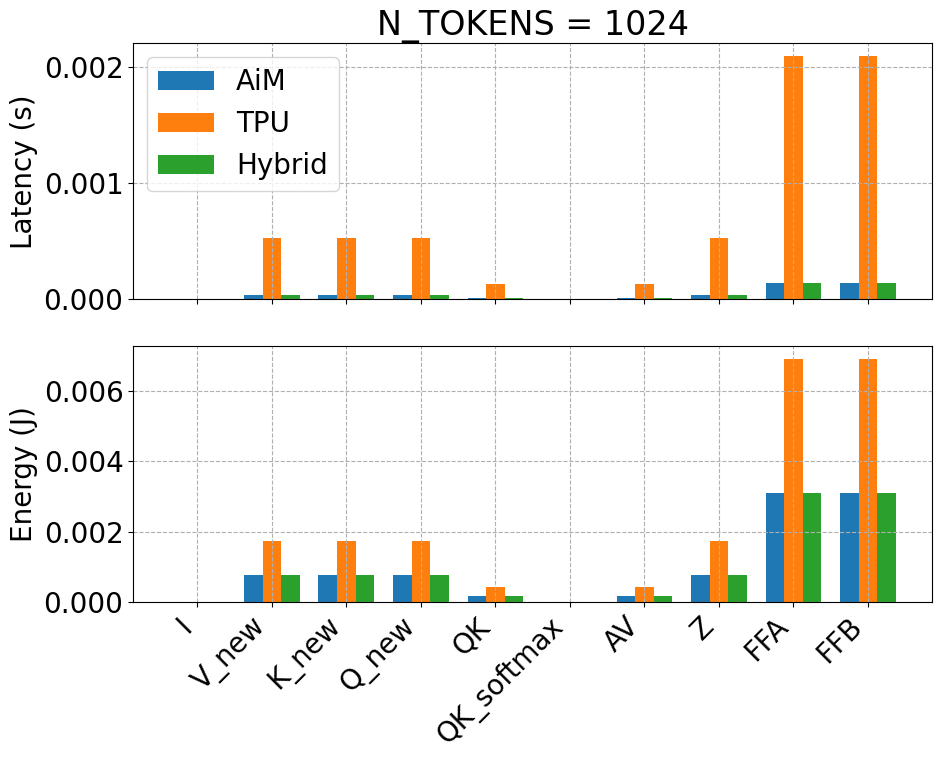

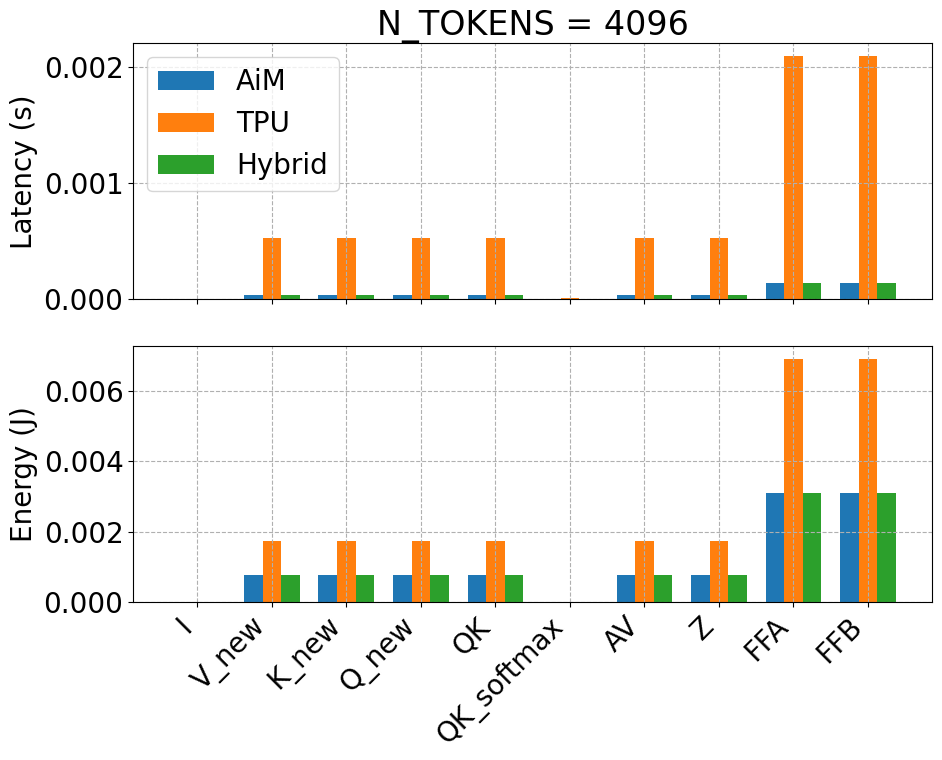

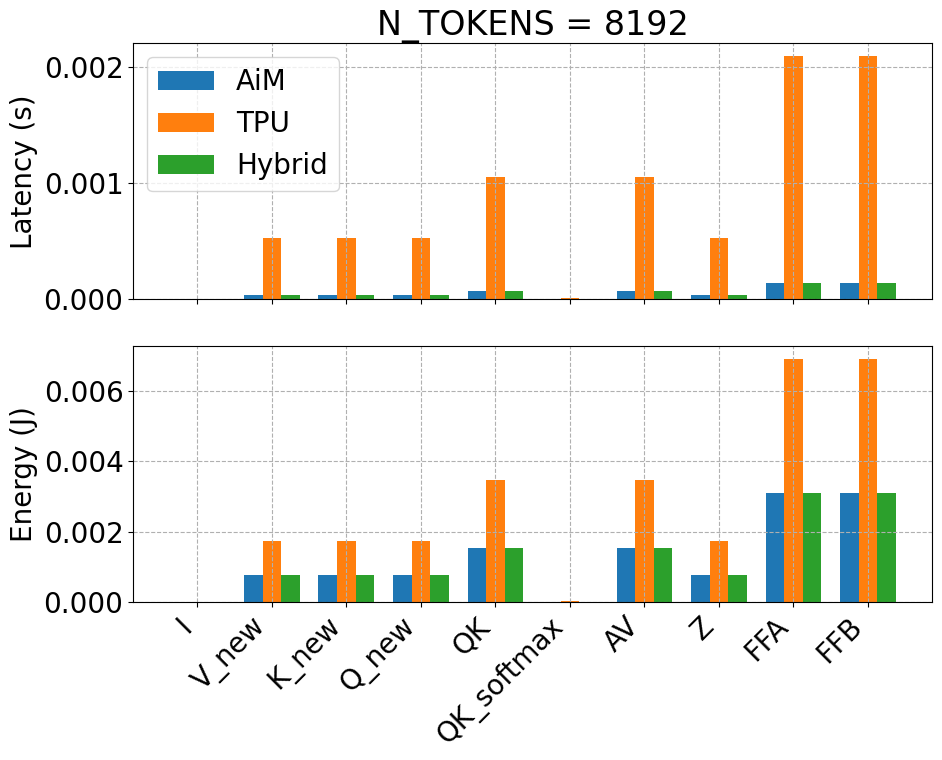

In [26]:
plot_energy_and_latency_breakdowns(DECODE_CACHE_FILE, "decode")

### Roofline Plots

WARNING Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


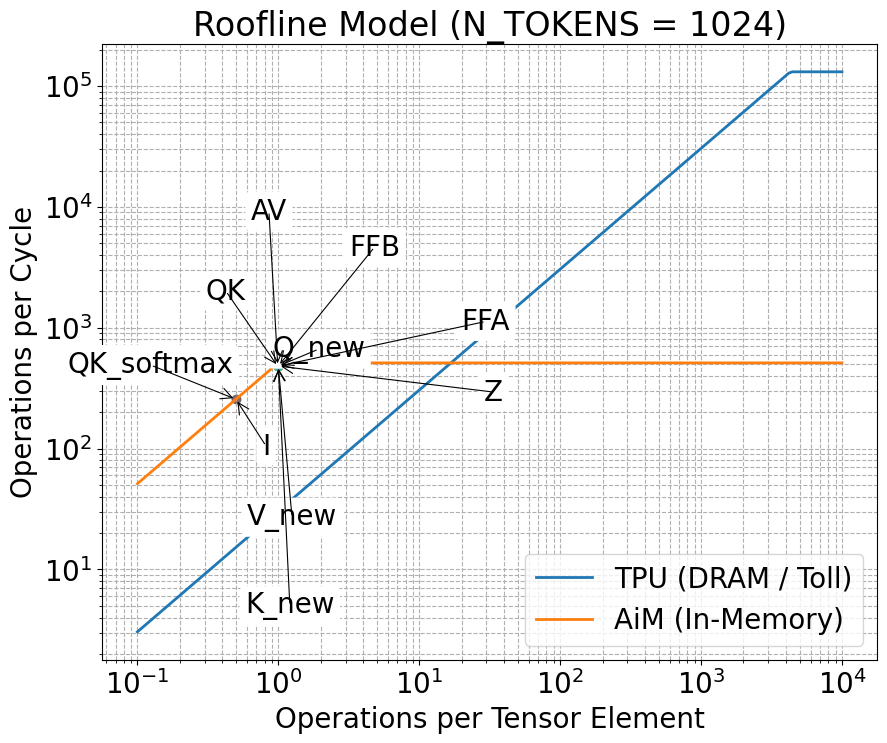

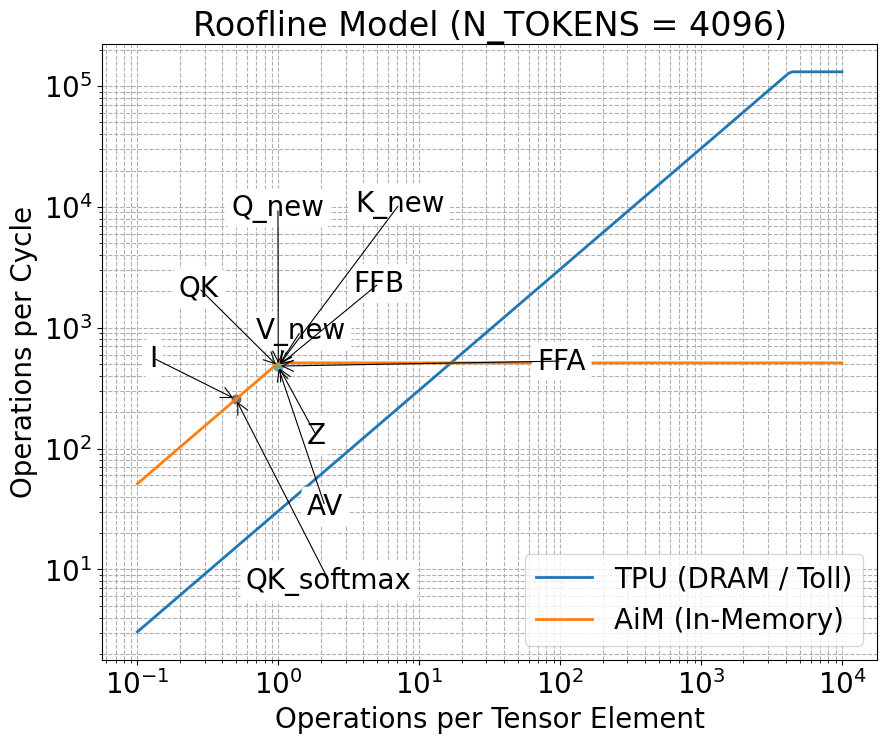

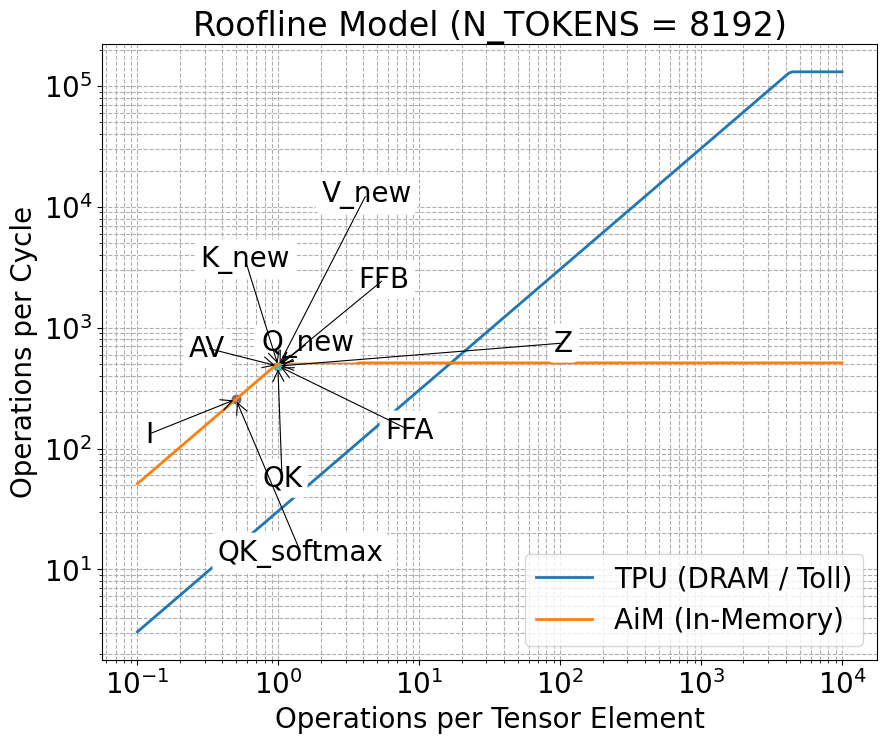

In [27]:
plot_roofline_plots(DECODE_CACHE_FILE, "lower right", "decode")

## Prefill

### Energy and Latency Breakdown

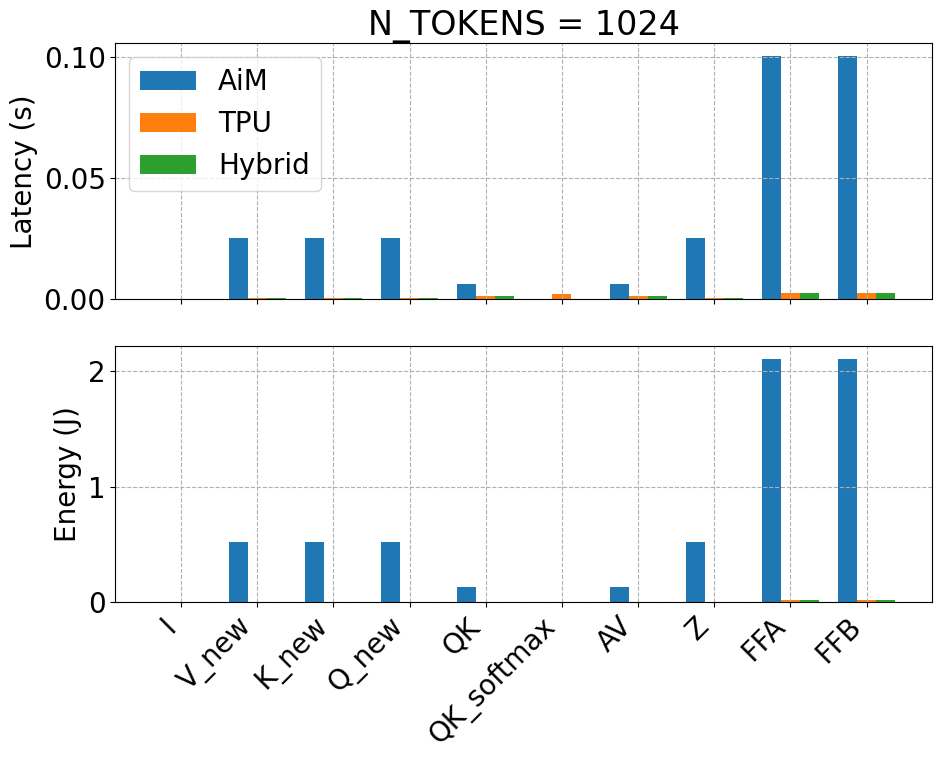

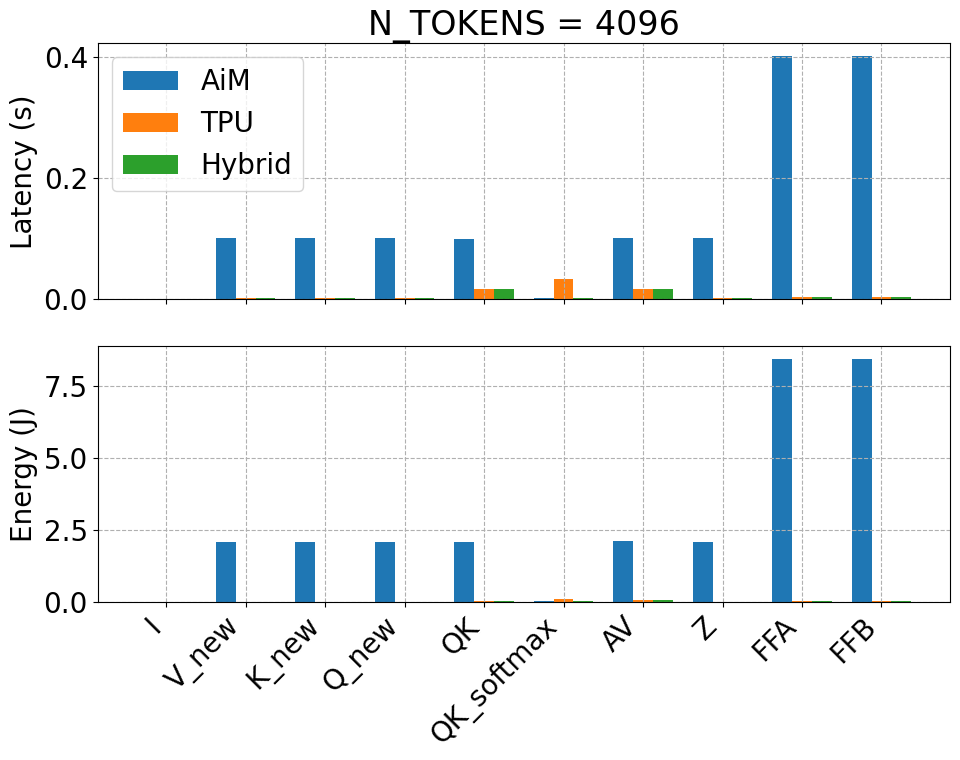

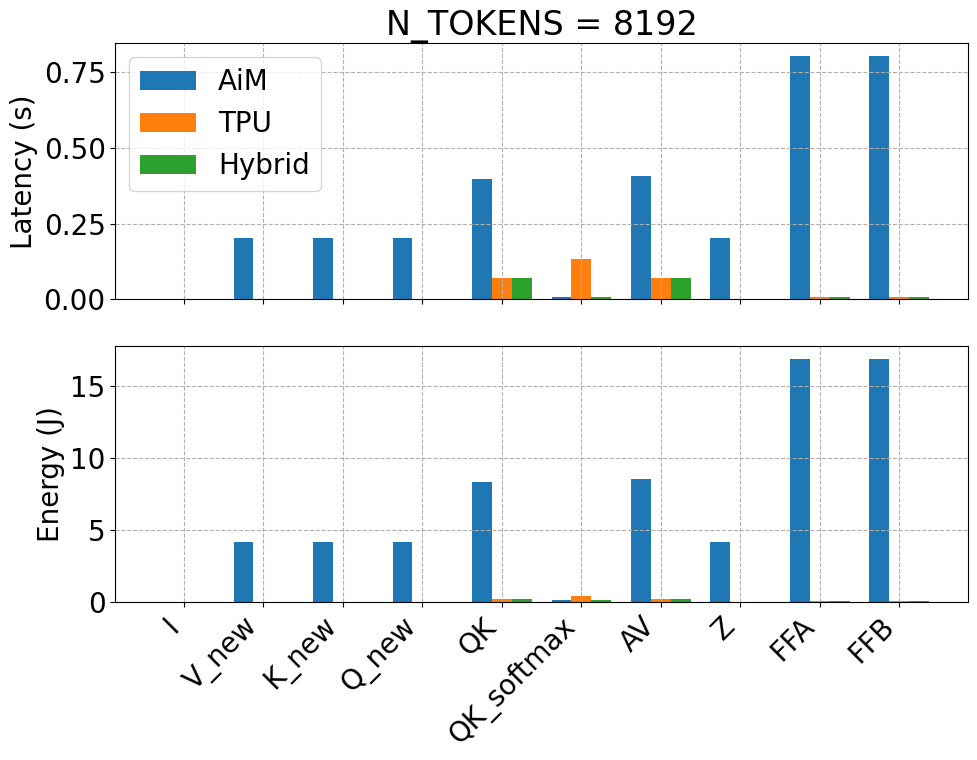

In [28]:
plot_energy_and_latency_breakdowns(PREFILL_CACHE_FILE, "prefill")

### Roofline Plots

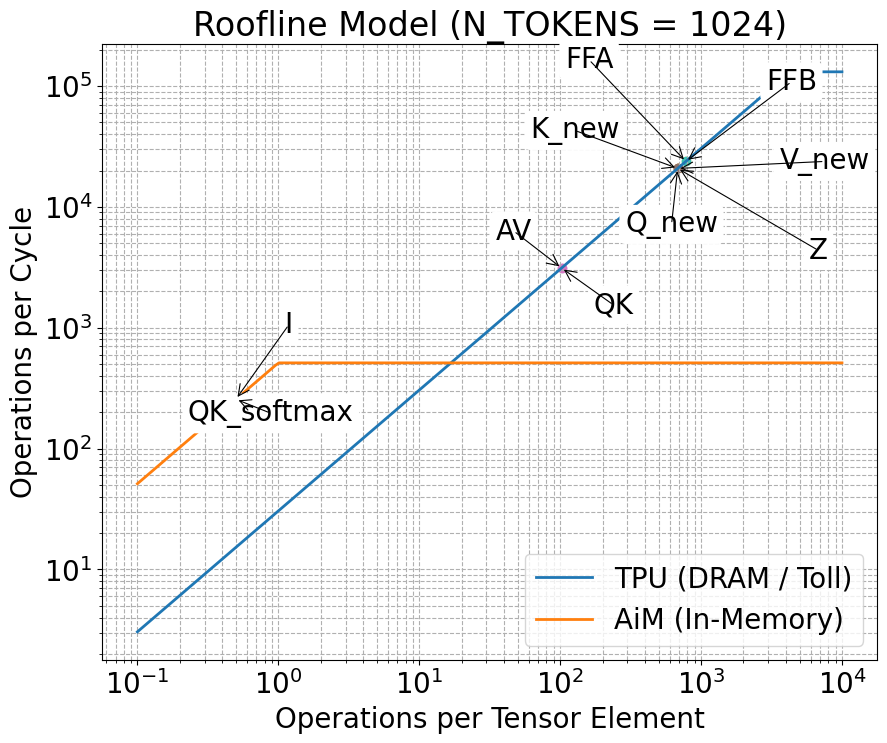

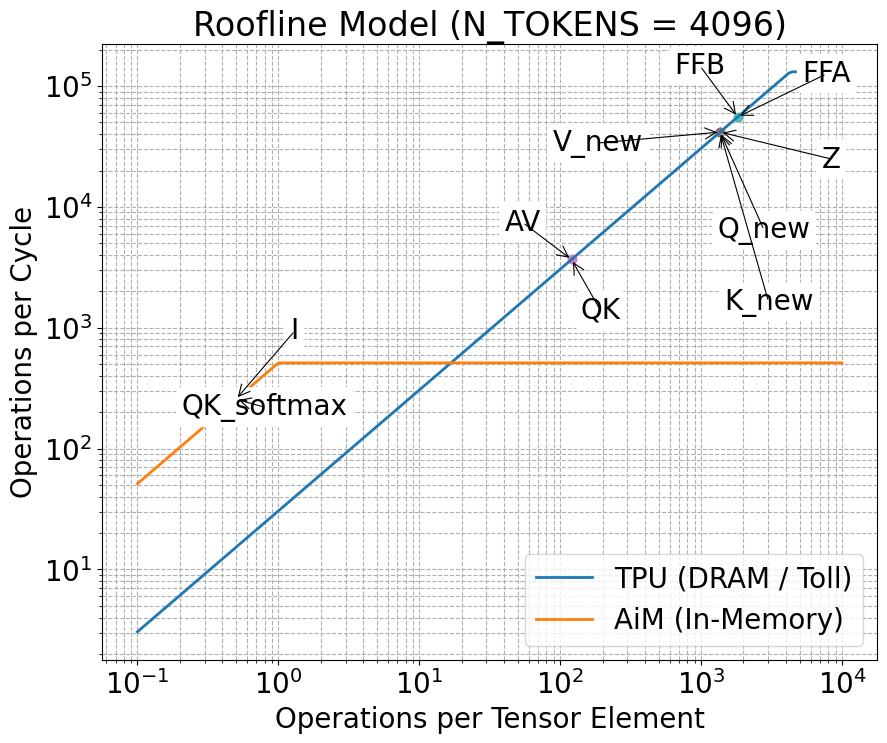

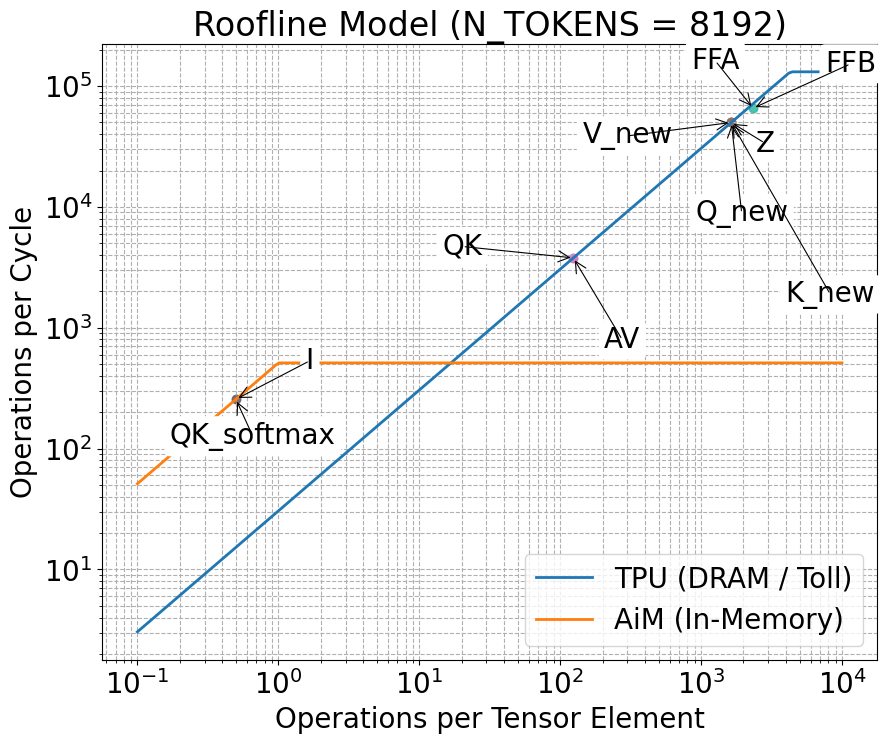

In [29]:
plot_roofline_plots(PREFILL_CACHE_FILE, "lower right", "prefill")